In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
#library(Seurat)
#library(Signac)
library(SeuratData)
library(SeuratDisk)
library(Matrix)

# genome info
library(GenomeInfoDb)
library(ggplot2)
library(patchwork)
library(stringr)
library(BSgenome.Drerio.UCSC.danRer11)

print(R.version)
print(packageVersion("Seurat"))

Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:Matrix’:

    expand, unname


The following object is masked from ‘package:utils’:

    findMatches


The following object

               _                           
platform       x86_64-pc-linux-gnu         
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          3.2                         
year           2023                        
month          10                          
day            31                          
svn rev        85441                       
language       R                           
version.string R version 4.3.2 (2023-10-31)
nickname       Eye Holes                   
[1] ‘4.4.0’


In [2]:
getwd()

[1] "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/notebooks/Fig1_atlas_QC"

In [2]:
# import the Seurat object
# assays: RNA, integrated_peaks
# contains connectivities from each modality (RNA, integrated_peaks(ATAC), and WNN)
seurat <- readRDS("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_ga_master.rds")
seurat

An object of class Seurat 
726060 features across 95196 samples within 5 assays 
Active assay: peaks_integrated (640831 features, 0 variable features)
 4 other assays present: RNA, SCT, integrated, Gene.Activity
 9 dimensional reductions calculated: integrated_lsi, umap, integrated_pca, umap.rna, umap.atac, wnn.umap, umap.rna.3D, umap.atac.3D, wnn.umap.3D

In [ ]:
# # import the individual object
# rna_integrated <- readRDS("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/")
# atac_integrated <- readRDS("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/")

In [5]:
# import the cell_ids from the filtered object
metadata <- read.csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/master_rna_atac_metadata.csv")
metadata %>% head()

,X,orig_ident,nCount_RNA,nFeature_RNA,nCount_ATAC,nFeature_ATAC,nucleosome_signal,nucleosome_percentile,TSS_enrichment,TSS_percentile,⋯,dataset,integrated_weight,peaks_integrated_weight,wsnn_res_0_8,seurat_clusters,data_source,annotation_ML,scANVI_zscape,annotation_ML_coarse,dev_stage
,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AAACAGCCACCTAAGC-1_1,SeuratProject,6522,2317,21425,9781,0.5719844,0.40,4.488213,0.48,⋯,TDR118,4.062589e-01,0.5937411,2,10,multiome,epidermis,contains head vasculature?,epidermis,15somites
2,AAACAGCCAGGGAGGA-1_1,SeuratProject,6100,2319,10334,5028,0.4481434,0.13,4.795205,0.75,⋯,TDR118,7.616462e-01,0.2383538,8,16,multiome,pronephros,vascular smooth muscle,pronephros,15somites
3,AAACAGCCATAGACCC-1_1,SeuratProject,12581,3467,51485,19874,0.5142133,0.24,5.238692,0.92,⋯,TDR118,5.938950e-08,0.9999999,6,14,multiome,hindbrain,fin bud mesoderm (pectoral),hindbrain,15somites
4,AAACATGCAAACTCAT-1_1,SeuratProject,5642,2145,19812,9183,0.6733186,0.85,4.409525,0.41,⋯,TDR118,3.694048e-01,0.6305952,0,0,multiome,spinal_cord,posterior spinal cord progenitors,spinal_cord,15somites
5,AAACATGCAAGGACCA-1_1,SeuratProject,2691,838,5182,2565,0.3949045,0.06,4.939061,0.83,⋯,TDR118,3.265597e-02,0.9673440,23,3,multiome,neural_optic2,pharynx,neural_optic,15somites
6,AAACATGCAAGGATTA-1_1,SeuratProject,4233,1703,24072,10949,0.6424510,0.72,4.636479,0.62,⋯,TDR118,5.023156e-01,0.4976844,34,4,multiome,neural_floor_plate,differentiating neuron (hindbrain),neural_floor_plate,15somites


In [11]:
# subset the Seurat object using "cell_ids" from the metadata (filtering out the low_quality cells)
cell_ids_to_keep <- metadata$X
# Subset the Seurat object
seurat_subset <- subset(seurat, cells = cell_ids_to_keep)
seurat_subset

An object of class Seurat 
726060 features across 94562 samples within 5 assays 
Active assay: peaks_integrated (640831 features, 0 variable features)
 4 other assays present: RNA, SCT, integrated, Gene.Activity
 9 dimensional reductions calculated: integrated_lsi, umap, integrated_pca, umap.rna, umap.atac, wnn.umap, umap.rna.3D, umap.atac.3D, wnn.umap.3D

In [12]:
seurat@graphs$wknn

list()

In [ ]:
# save the wknn (connectivities)
write.csv(seurat@graphs$wknn,
          "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/wknn.csv")   

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 67.5 GiB”


In [ ]:
# import the cell_ids from the filtered object (filtering out "low quality cells"

# then, export the 

In [ ]:
                 write.csv(pbmc@neighbors$weighted.nn@nn.idx, 
          "/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/neighbors_indices.csv")

write.csv(pbmc@neighbors$weighted.nn@nn.dist, 
          "/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/distances.csv")

write.csv(pbmc@graphs$wknn,
          "/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/connectivities")                                                                                                                                     

In [15]:
meta %>% head() 

,X,n_genes_by_counts,pct_counts_mt,n_counts,n_genes,size_factors,phase,leiden_final,atac_ann,cell_type,⋯,nucleosome_signal,rna_ann,cell_type_RNA,cell_type_ATAC,GEX_leiden_015,ATAC_leiden_015,manual_annotation_fine,manual_annotation_coarse,joint_leiden_015,joint_leiden_05
,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>
AAACAGCCAATTAAGG-1,AAACAGCCAATTAAGG-1,1088,1.0578718,1607,1088,0.4751749,G2M,CD4+ T naive,CD4+ T naive,CD4+ T naive,⋯,0.6885246,CD4+ T naive,CD4+ T naive,CD4+ T naive,0,5,CD4+T,T_cells,0,3
AAACAGCCAGGCTGTT-1,AAACAGCCAGGCTGTT-1,2663,2.4925647,7061,2663,1.8318003,G2M,Lymph prog,Lymph prog,Lymph prog,⋯,0.9993252,Lymph prog,Lymph prog,Lymph prog,7,8,Lymph_prog,unassigned,6,9
AAACATGCAAAGCGCA-1,AAACATGCAAAGCGCA-1,1162,0.7786429,1798,1162,0.5871742,G2M,CD4+ T naive,CD4+ T activated,CD4+ T activated,⋯,1.1462141,CD4+ T naive,CD4+ T naive,CD4+ T activated,0,1,CD4+T,T_cells,0,7
AAACATGCAATAACCT-1,AAACATGCAATAACCT-1,1224,0.7076350,2685,1224,0.5724250,G2M,Erythroblast,"Proerythroblast, Erythroblast",Erythroblast,⋯,0.9327884,Erythroblast,Erythroblast,"Proerythroblast, Erythroblast",2,2,unassigned,unassigned,2,1
AAACATGCAATAATGG-1,AAACATGCAATAATGG-1,987,1.2517385,1438,987,0.4134888,S,CD8+ T,"CD4+ T activated, CD8+ T",CD8+ T,⋯,0.7079137,CD8+ T,CD8+ T,"CD4+ T activated, CD8+ T",3,3,CD8+T,T_cells,0,2
AAACATGCAATATAGG-1,AAACATGCAATATAGG-1,1084,0.5171300,1547,1084,0.5075861,S,CD4+ T activated,CD4+ T activated,CD4+ T activated,⋯,1.0549872,CD4+ T activated,CD4+ T activated,CD4+ T activated,0,1,CD4+T,T_cells,0,7


In [94]:
# QC with the cell_ids from the neurips final object
cell_ids<-rownames(meta)
pbmc <- subset(pbmc, cells = cell_ids)

## Sorting the order of cells using cell_ids alphabetically

In [111]:
# Get the order of the cell IDs
new_order <- order(rownames(pbmc@assays$RNA@data))

# Set the cell identities based on the new order
pbmc <- SetIdent(pbmc, value = new_order)
pbmc

An object of class Seurat 
161077 features across 6224 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 1 other assay present: ATAC

In [119]:
pbmc@meta.data %>% head() 

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_ATAC,nFeature_ATAC,nCount_SCT,nFeature_SCT,SCT.weight,ATAC.weight,wsnn_res.0.8,seurat_clusters
,<fct>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<fct>,<fct>
AAACAGCCAATTAAGG-1,SeuratProject,1832,1204,1.0371179,8256,3811,1994,1203,0.4775704,0.5224296,3,3
AAACAGCCAGGCTGTT-1,SeuratProject,8032,2917,2.3904382,19866,8519,2297,1113,0.5792240,0.4207760,10,10
AAACATGCAAAGCGCA-1,SeuratProject,2123,1307,0.8007537,10646,4974,2142,1304,0.5806327,0.4193673,4,4
AAACATGCAATAACCT-1,SeuratProject,3088,1355,0.7448187,22412,8116,2704,1354,0.4004532,0.5995468,1,1
AAACATGCAATAATGG-1,SeuratProject,1604,1081,1.1221945,9012,4163,1930,1078,0.4450565,0.5549435,2,2
AAACATGCAATATAGG-1,SeuratProject,1808,1214,0.4977876,10913,4883,1978,1214,0.7172909,0.2827091,4,4


In [24]:
pbmc

An object of class Seurat 
183057 features across 6224 samples within 3 assays 
Active assay: ATAC (124476 features, 124476 variable features)
 2 other assays present: RNA, SCT
 5 dimensional reductions calculated: pca, umap.rna, lsi, umap.atac, wnn.umap

In [23]:
pbmc@meta.data %>% head() 

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_ATAC,nFeature_ATAC,nCount_SCT,nFeature_SCT,SCT.weight,ATAC.weight,wsnn_res.0.8,seurat_clusters
,<fct>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<fct>,<fct>
AAACAGCCAATTAAGG-1,SeuratProject,1832,1204,1.0371179,8256,3811,1994,1203,0.4775704,0.5224296,3,3
AAACAGCCAGGCTGTT-1,SeuratProject,8032,2917,2.3904382,19866,8519,2297,1113,0.5792240,0.4207760,10,10
AAACATGCAAAGCGCA-1,SeuratProject,2123,1307,0.8007537,10646,4974,2142,1304,0.5806327,0.4193673,4,4
AAACATGCAATAACCT-1,SeuratProject,3088,1355,0.7448187,22412,8116,2704,1354,0.4004532,0.5995468,1,1
AAACATGCAATAATGG-1,SeuratProject,1604,1081,1.1221945,9012,4163,1930,1078,0.4450565,0.5549435,2,2
AAACATGCAATATAGG-1,SeuratProject,1808,1214,0.4977876,10913,4883,1978,1214,0.7172909,0.2827091,4,4


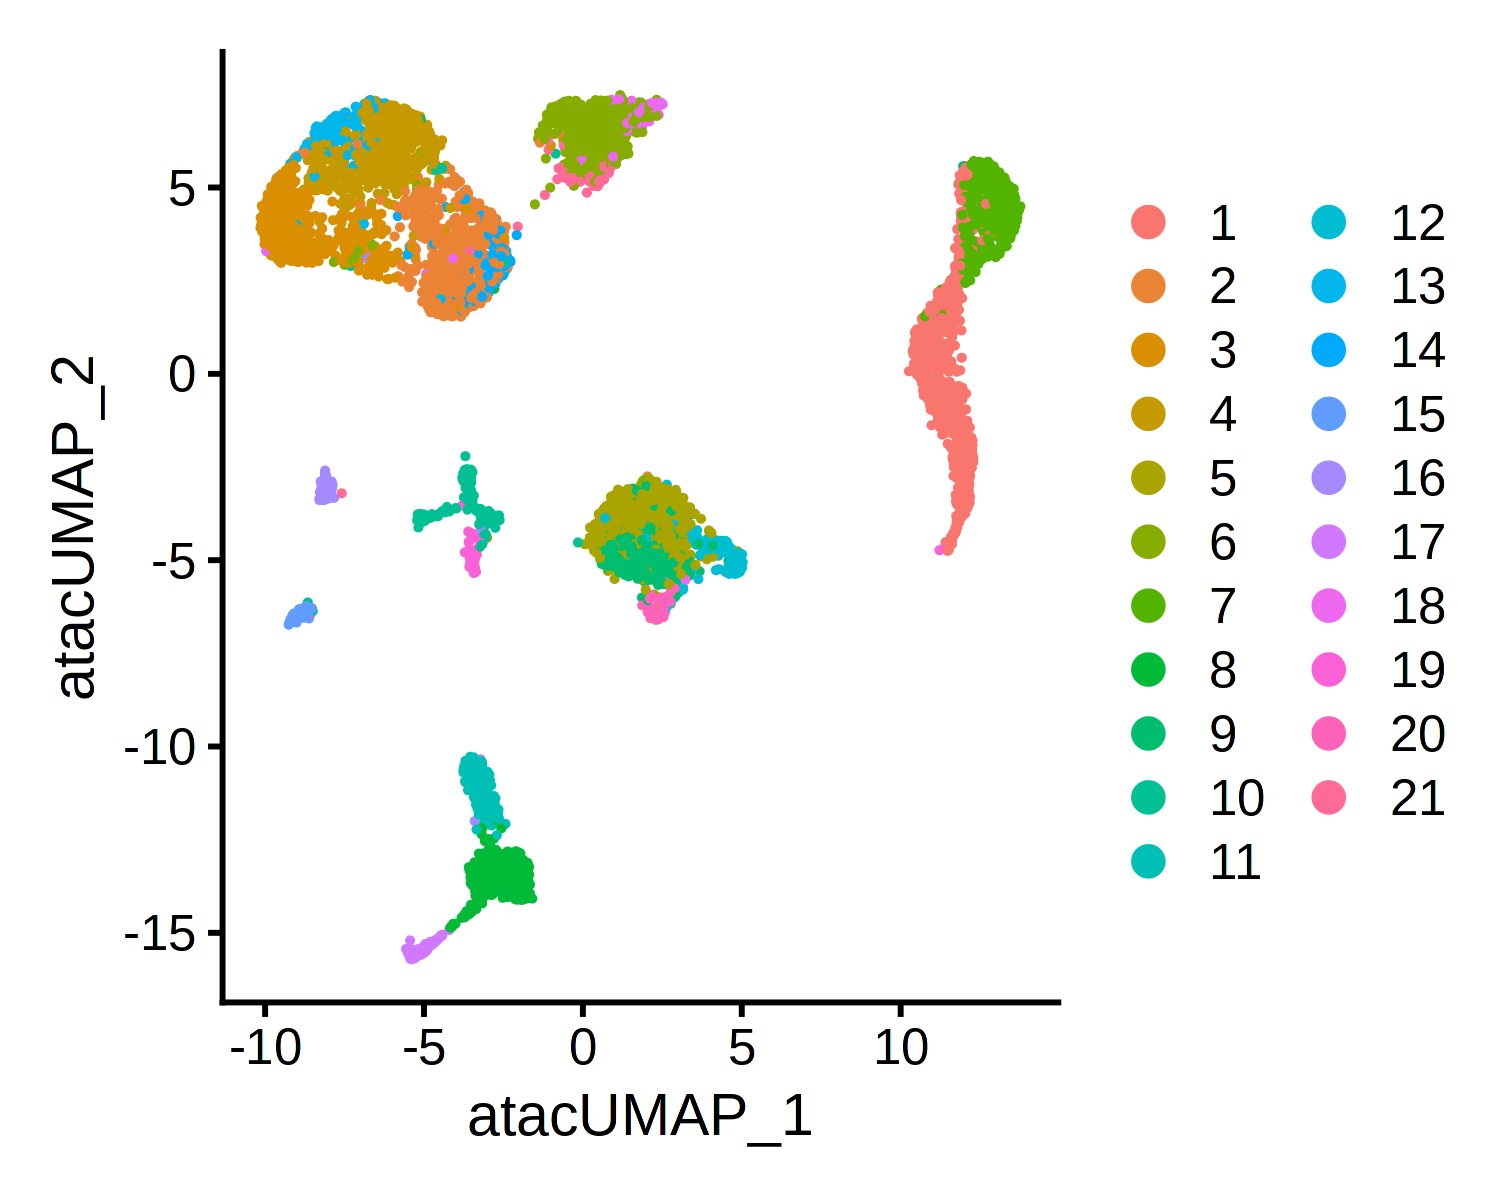

In [121]:
options(repr.plot.width=5, repr.plot.height=4)
options(repr.plot.res=300)
DimPlot(pbmc)

In [122]:
meta = read.csv('/mnt/ibm_lg/alejandro/neurIPS/cell_annotation_paper/data/metadata.csv')
row.names(meta) <- meta$X

In [123]:
meta %>% head() 

,X,n_genes_by_counts,pct_counts_mt,n_counts,n_genes,size_factors,phase,leiden_final,atac_ann,cell_type,⋯,nucleosome_signal,rna_ann,cell_type_RNA,cell_type_ATAC,GEX_leiden_015,ATAC_leiden_015,manual_annotation_fine,manual_annotation_coarse,joint_leiden_015,joint_leiden_05
,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>
AAACAGCCAATTAAGG-1,AAACAGCCAATTAAGG-1,1088,1.0578718,1607,1088,0.4751749,G2M,CD4+ T naive,CD4+ T naive,CD4+ T naive,⋯,0.6885246,CD4+ T naive,CD4+ T naive,CD4+ T naive,0,5,CD4+T,T_cells,0,3
AAACAGCCAGGCTGTT-1,AAACAGCCAGGCTGTT-1,2663,2.4925647,7061,2663,1.8318003,G2M,Lymph prog,Lymph prog,Lymph prog,⋯,0.9993252,Lymph prog,Lymph prog,Lymph prog,7,8,Lymph_prog,unassigned,6,9
AAACATGCAAAGCGCA-1,AAACATGCAAAGCGCA-1,1162,0.7786429,1798,1162,0.5871742,G2M,CD4+ T naive,CD4+ T activated,CD4+ T activated,⋯,1.1462141,CD4+ T naive,CD4+ T naive,CD4+ T activated,0,1,CD4+T,T_cells,0,7
AAACATGCAATAACCT-1,AAACATGCAATAACCT-1,1224,0.7076350,2685,1224,0.5724250,G2M,Erythroblast,"Proerythroblast, Erythroblast",Erythroblast,⋯,0.9327884,Erythroblast,Erythroblast,"Proerythroblast, Erythroblast",2,2,unassigned,unassigned,2,1
AAACATGCAATAATGG-1,AAACATGCAATAATGG-1,987,1.2517385,1438,987,0.4134888,S,CD8+ T,"CD4+ T activated, CD8+ T",CD8+ T,⋯,0.7079137,CD8+ T,CD8+ T,"CD4+ T activated, CD8+ T",3,3,CD8+T,T_cells,0,2
AAACATGCAATATAGG-1,AAACATGCAATATAGG-1,1084,0.5171300,1547,1084,0.5075861,S,CD4+ T activated,CD4+ T activated,CD4+ T activated,⋯,1.0549872,CD4+ T activated,CD4+ T activated,CD4+ T activated,0,1,CD4+T,T_cells,0,7


In [124]:
# filter for the cells that passed the neurips QC
common_cells <- intersect(colnames(pbmc),row.names(meta))

In [125]:
pbmc <- AddMetaData(pbmc, metadata = meta[common_cells,])

In [126]:
names(pbmc@meta.data)

[1] "orig.ident"               "nCount_RNA"              
 [3] "nFeature_RNA"             "percent.mt"              
 [5] "nCount_ATAC"              "nFeature_ATAC"           
 [7] "nCount_SCT"               "nFeature_SCT"            
 [9] "SCT.weight"               "ATAC.weight"             
[11] "wsnn_res.0.8"             "seurat_clusters"         
[13] "X"                        "n_genes_by_counts"       
[15] "pct_counts_mt"            "n_counts"                
[17] "n_genes"                  "size_factors"            
[19] "phase"                    "leiden_final"            
[21] "atac_ann"                 "cell_type"               
[23] "nCount_peaks"             "atac_fragments"          
[25] "reads_in_peaks_frac"      "blacklist_fraction"      
[27] "nucleosome_signal"        "rna_ann"                 
[29] "cell_type_RNA"            "cell_type_ATAC"          
[31] "GEX_leiden_015"           "ATAC_leiden_015"         
[33] "manual_annotation_fine"   "manual_annotation_coarse"
[35] "joint_leiden_015"         "joint_leiden_05"

In [127]:
pbmc

An object of class Seurat 
183057 features across 6224 samples within 3 assays 
Active assay: ATAC (124476 features, 124476 variable features)
 2 other assays present: RNA, SCT
 5 dimensional reductions calculated: pca, umap.rna, lsi, umap.atac, wnn.umap

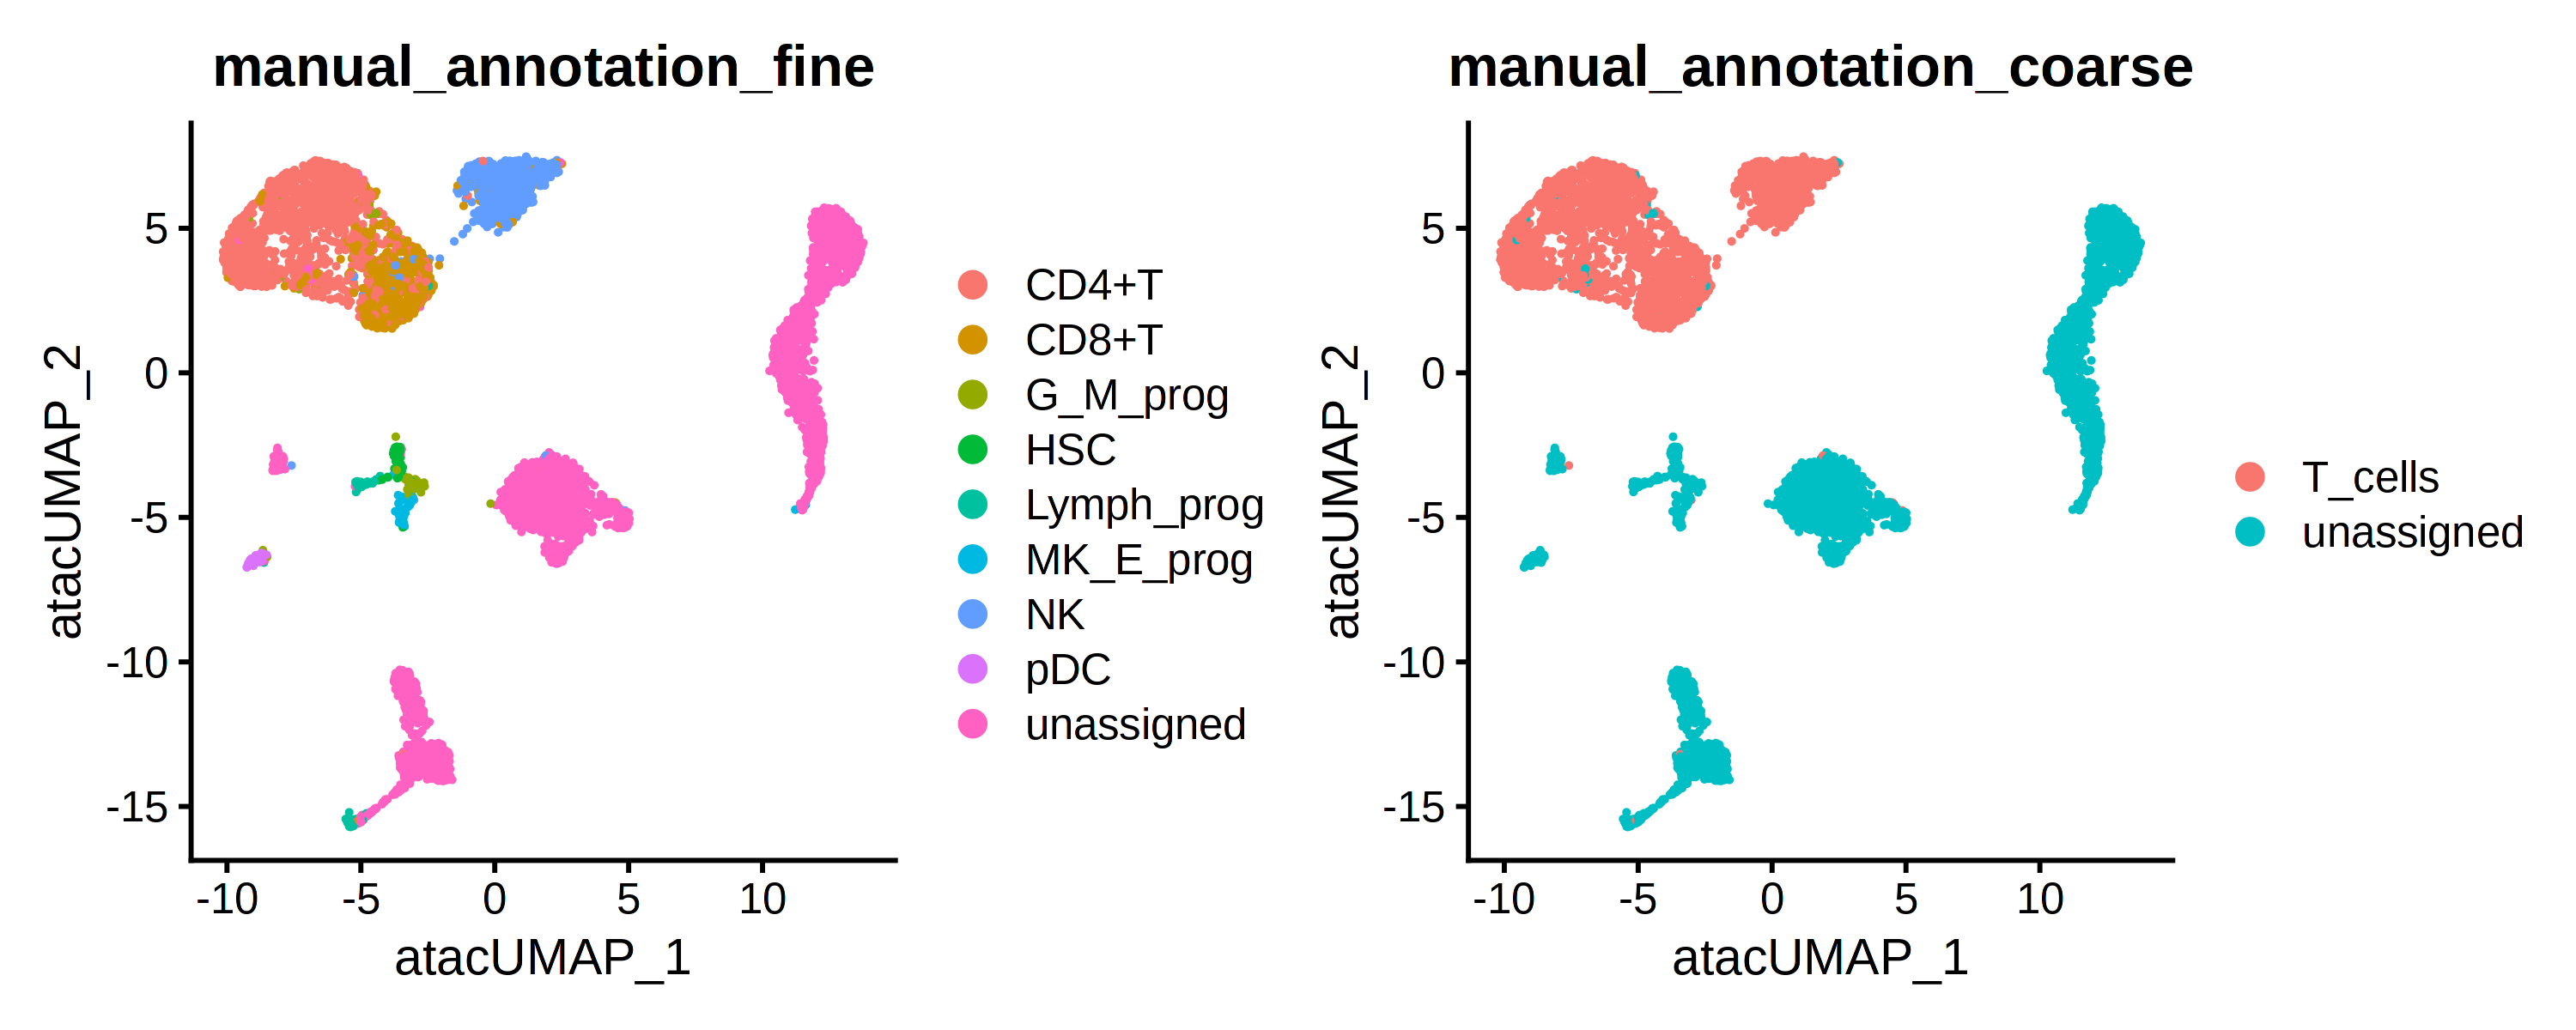

In [128]:
options(repr.plot.width=10, repr.plot.height=4)


DimPlot(pbmc, group.by = c('manual_annotation_fine', 'manual_annotation_coarse') ) 



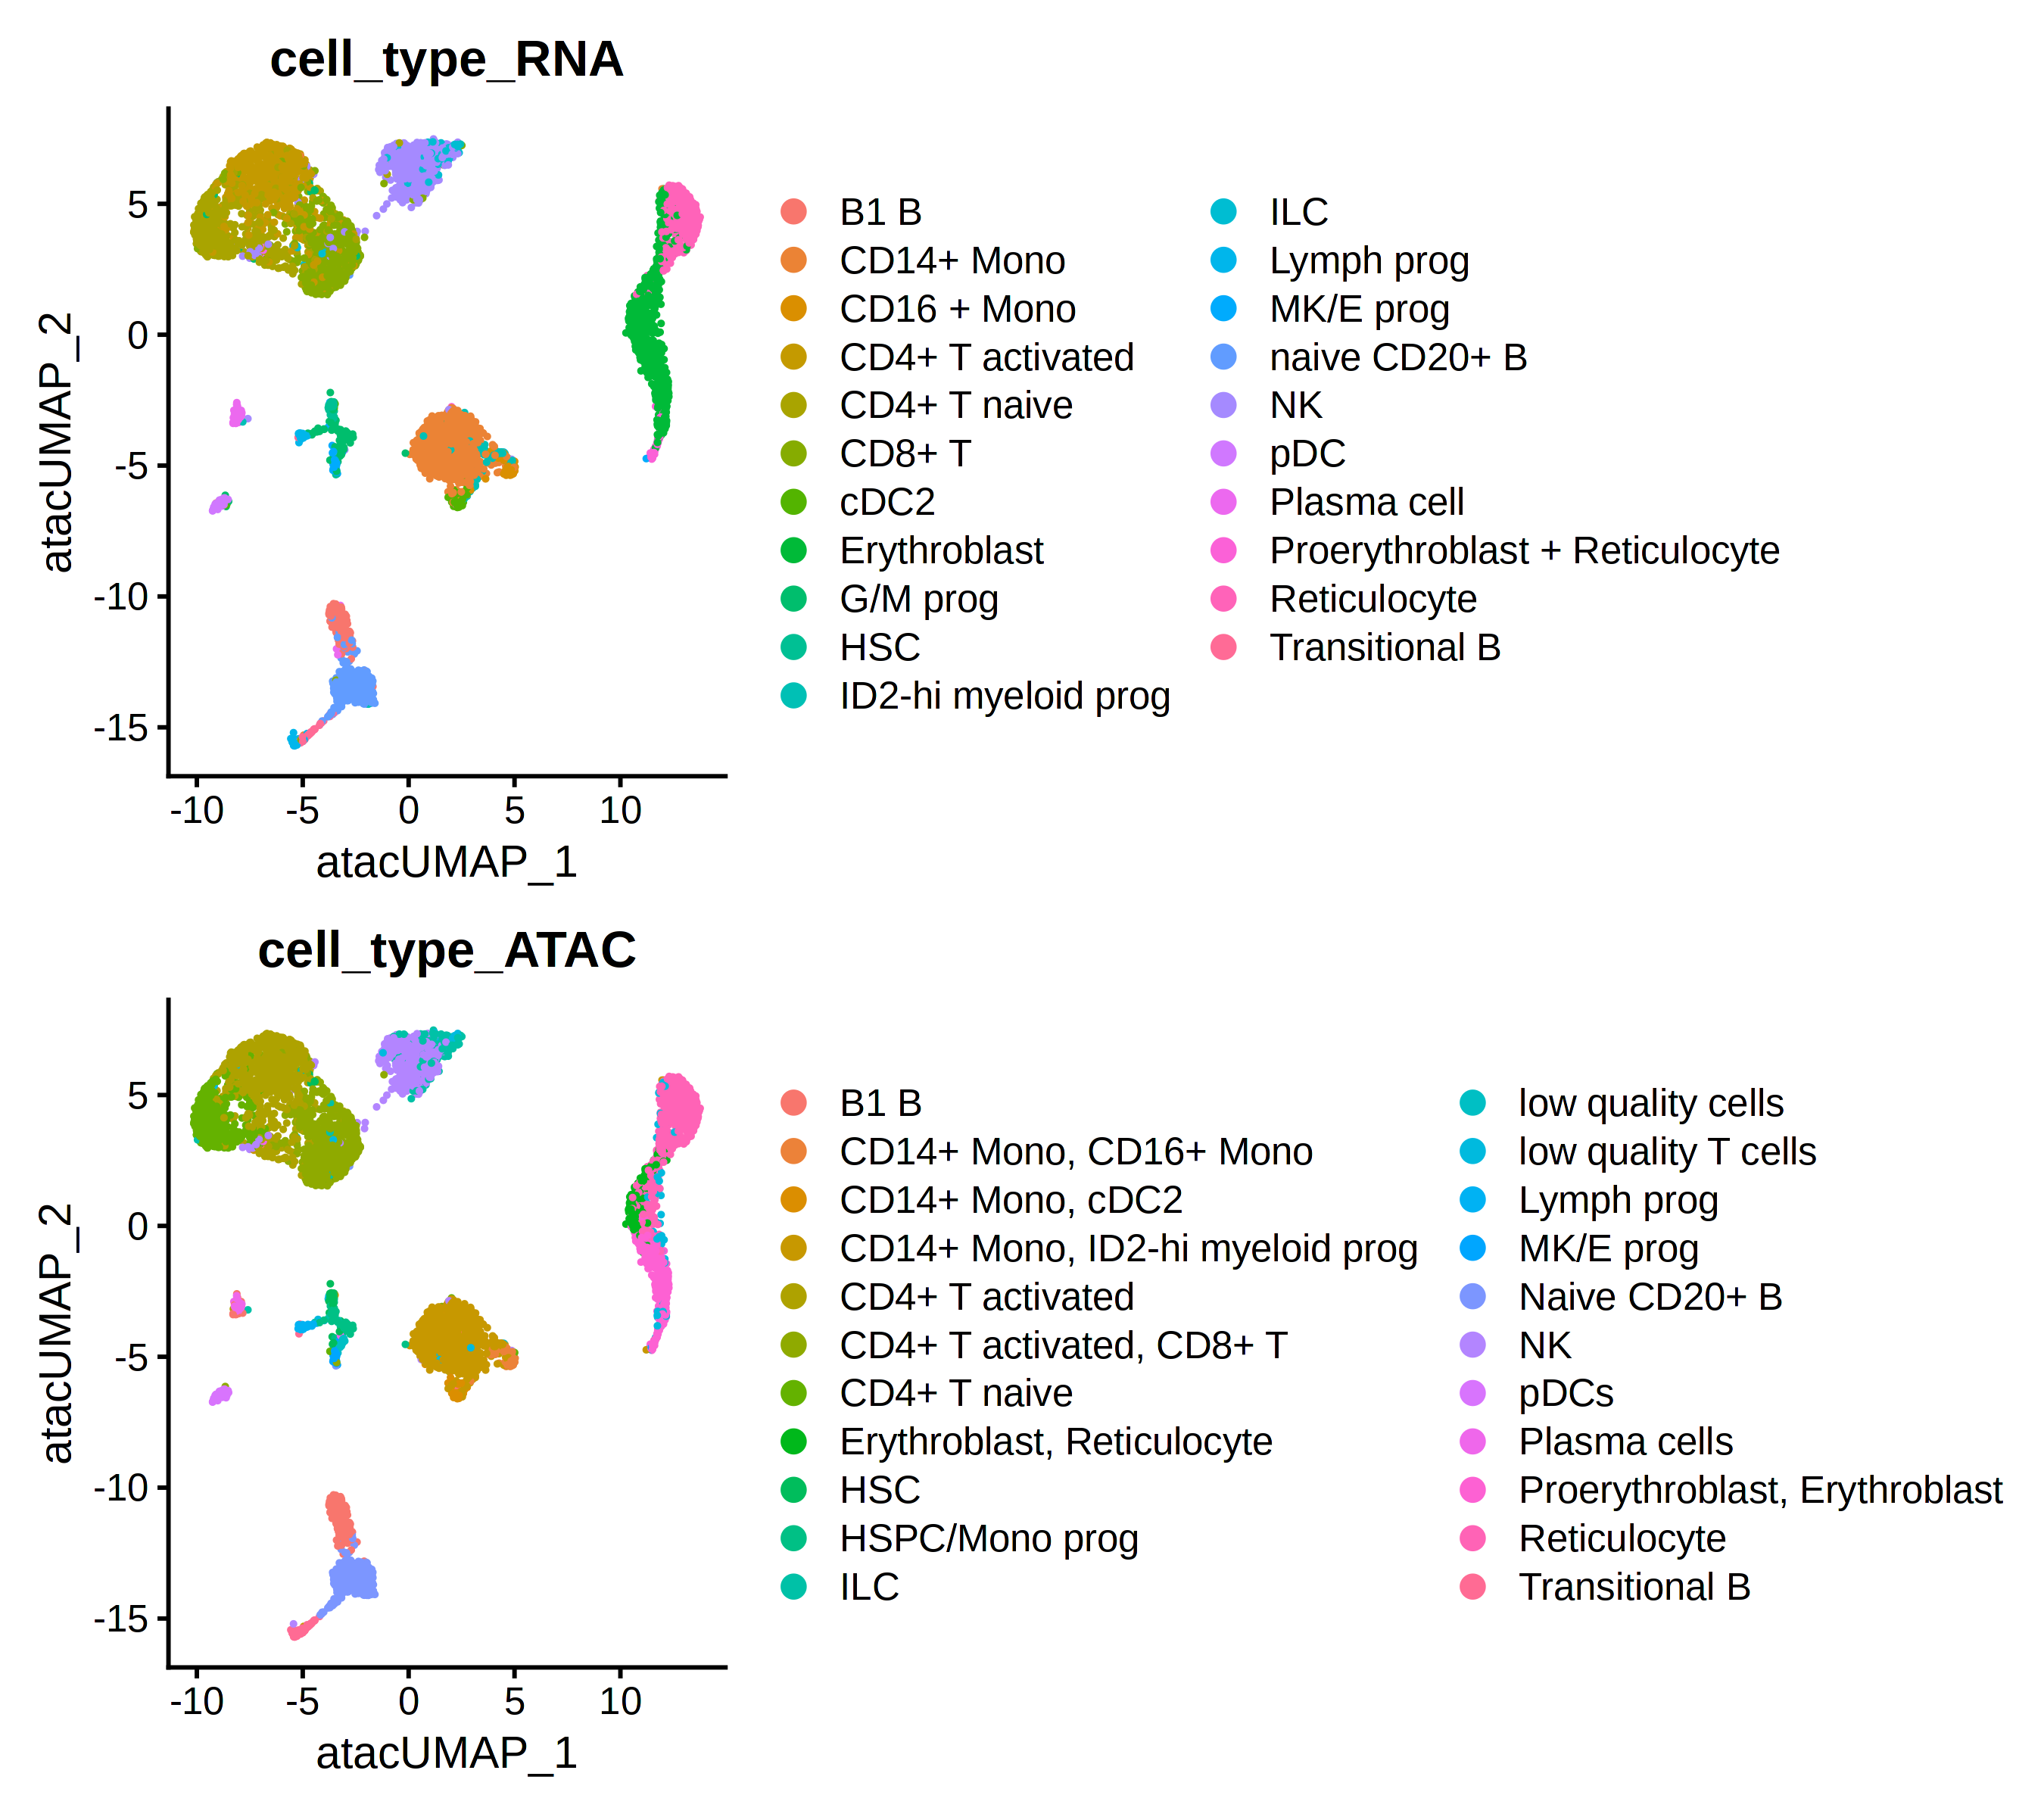

In [34]:

options(repr.plot.width=9, repr.plot.height=8)


DimPlot(pbmc, group.by = c('cell_type_RNA', 'cell_type_ATAC') ,ncol = 1) 


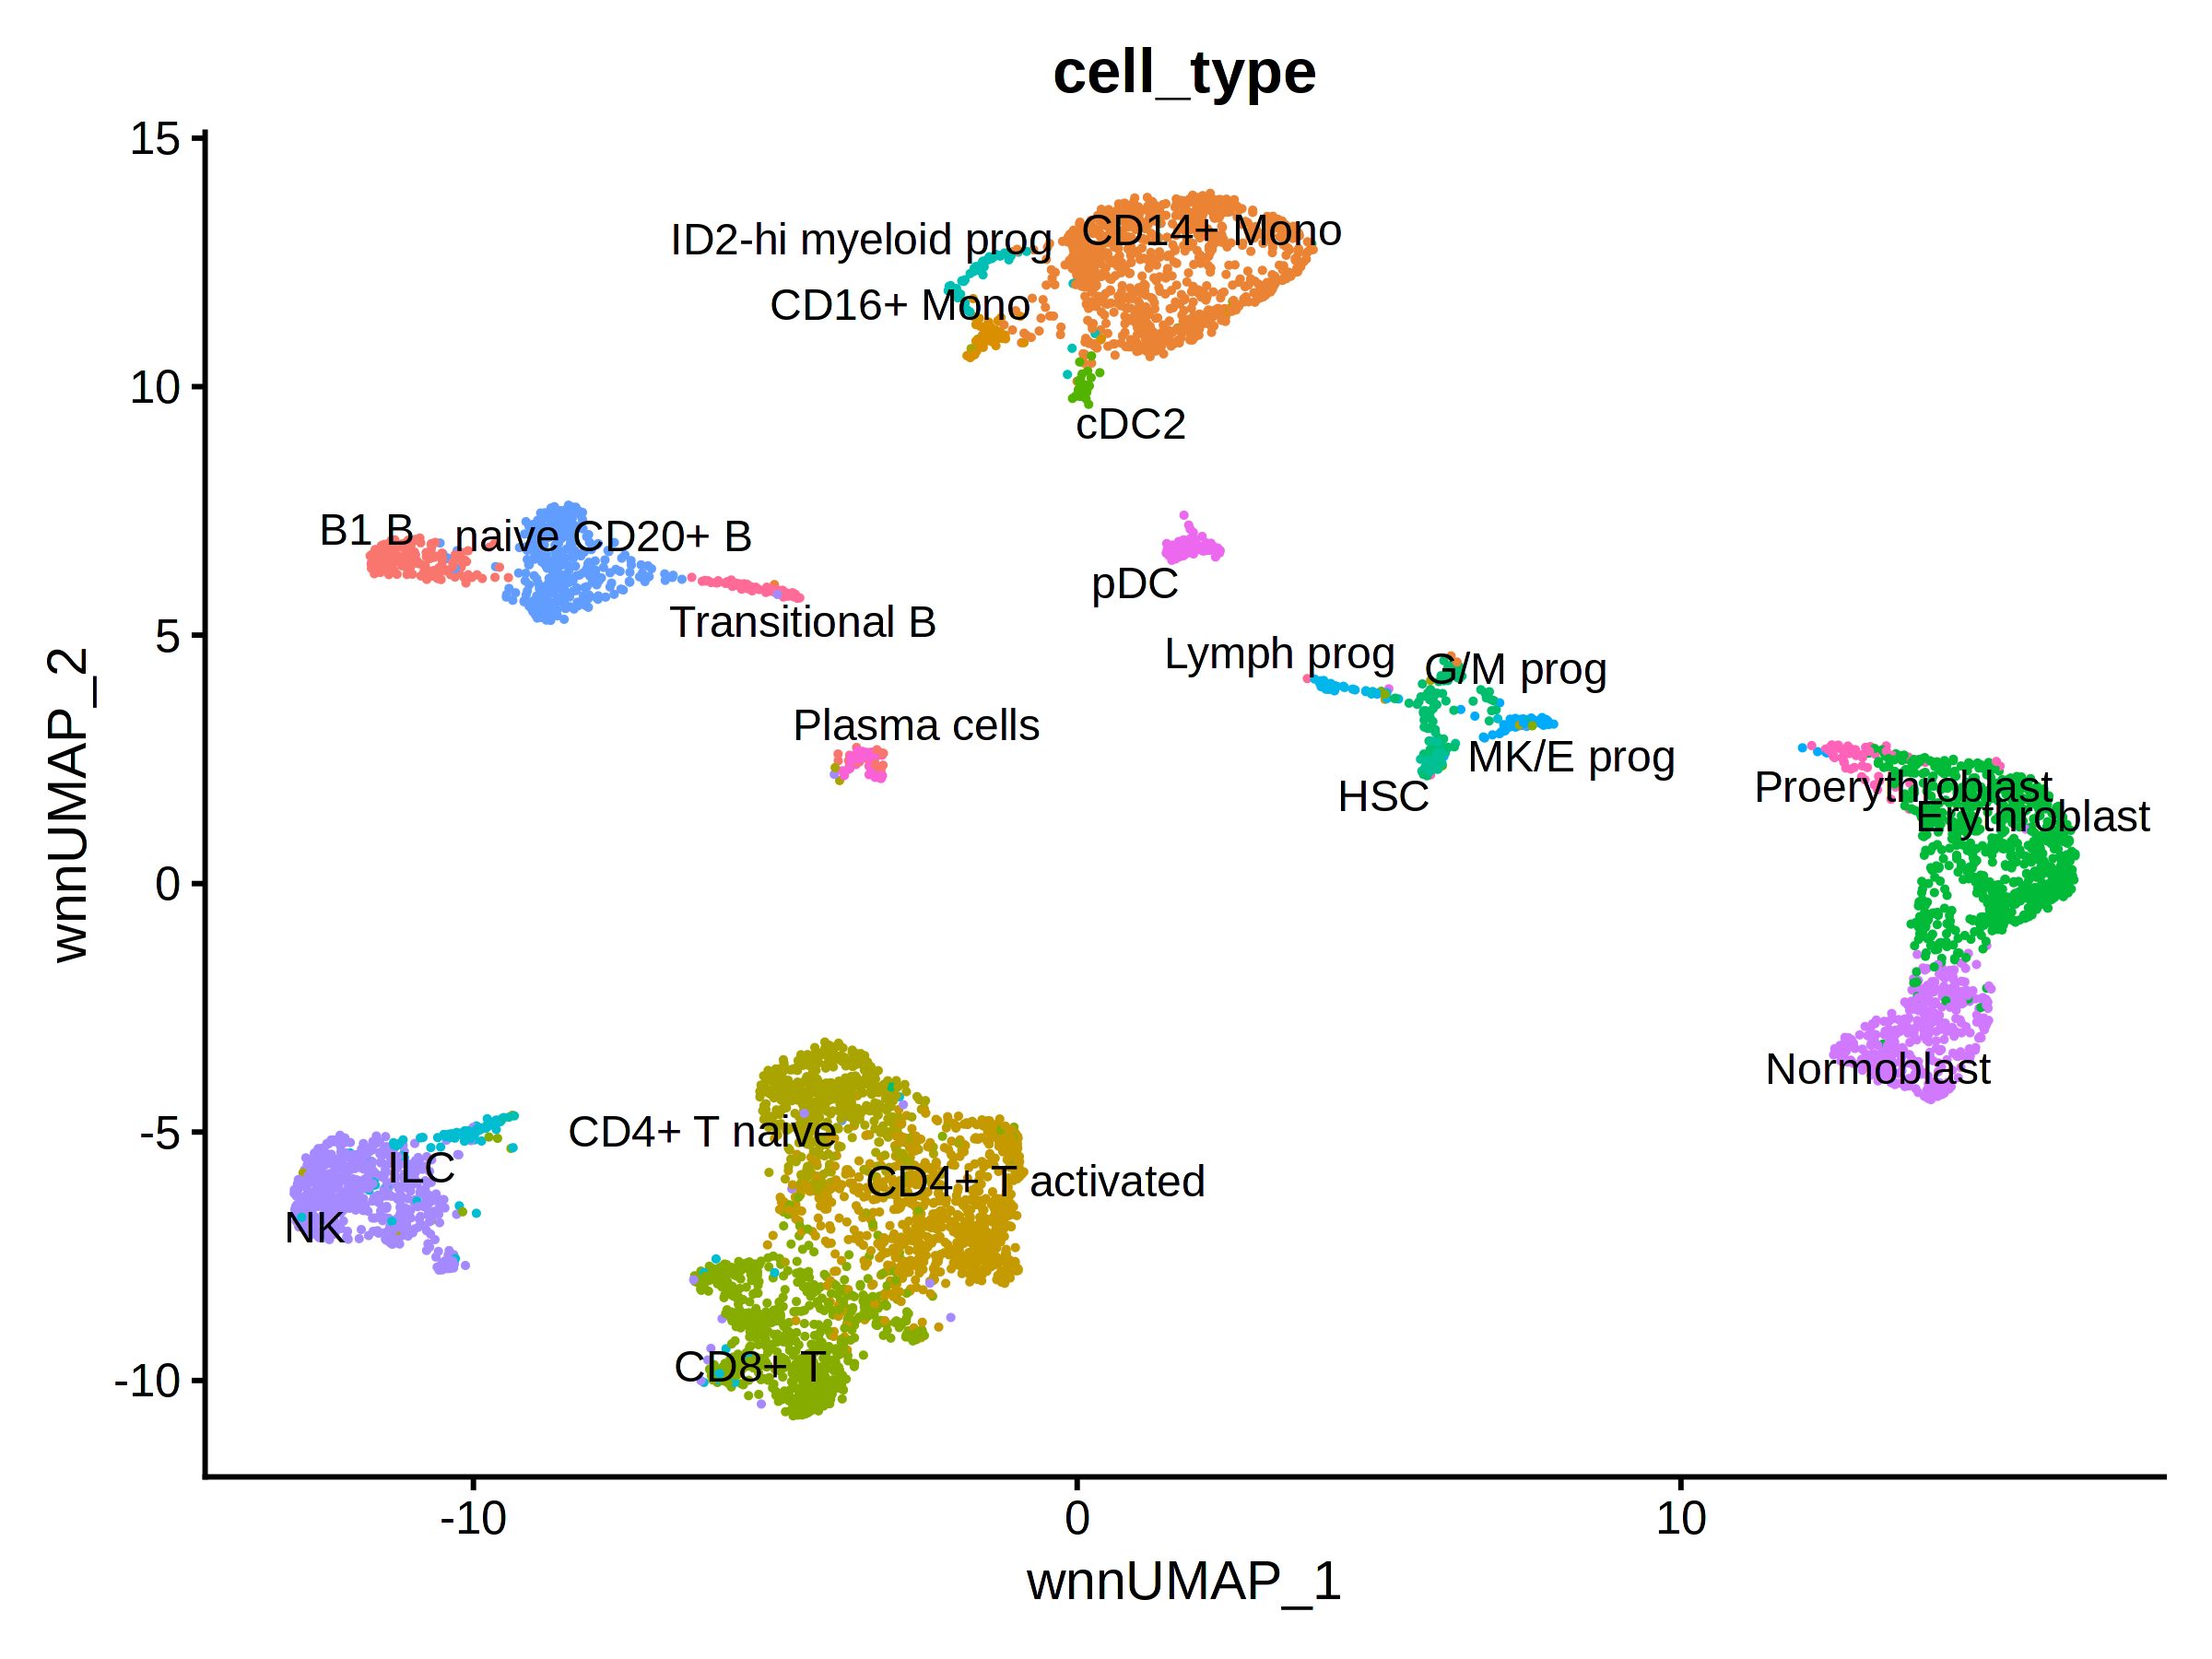

In [129]:
options(repr.plot.width=8, repr.plot.height=6)
DimPlot(pbmc, group.by = c('cell_type') ,
        reduction="wnn.umap", ncol = 1, 
        label=TRUE, repel=TRUE) +  NoLegend() 


In [37]:
wnn.umap <- pbmc@reductions$wnn.umap


In [130]:
# save the Seurat object
saveRDS(pbmc, "/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/s1d1_rna_atac_wnn_seurat.rds", 
        )

## Checking the weighted nearest neighbors (wnn)

In [132]:
neighborhood_matrix = pbmc@neighbors$weighted.nn@nn.dist
neighborhood_index =  pbmc@neighbors$weighted.nn@nn.idx
pbmc@graphs

  [[ suppressing 32 column names 'AAACAGCCAATTAAGG-1', 'AAACAGCCAGGCTGTT-1', 'AAACATGCAAAGCGCA-1' ... ]]

  [[ suppressing 32 column names 'AAACAGCCAATTAAGG-1', 'AAACAGCCAGGCTGTT-1', 'AAACATGCAAAGCGCA-1' ... ]]

  [[ suppressing 32 column names 'AAACAGCCAATTAAGG-1', 'AAACAGCCAGGCTGTT-1', 'AAACATGCAAAGCGCA-1' ... ]]

  [[ suppressing 32 column names 'AAACAGCCAATTAAGG-1', 'AAACAGCCAGGCTGTT-1', 'AAACATGCAAAGCGCA-1' ... ]]

  [[ suppressing 32 column names 'AAACAGCCAATTAAGG-1', 'AAACAGCCAGGCTGTT-1', 'AAACATGCAAAGCGCA-1' ... ]]

  [[ suppressing 32 column names 'AAACAGCCAATTAAGG-1', 'AAACAGCCAGGCTGTT-1', 'AAACATGCAAAGCGCA-1' ... ]]



$wknn
6224 x 6224 sparse Matrix of class "Graph"
                                                                                         
AAACAGCCAATTAAGG-1 1 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
AAACAGCCAGGCTGTT-1 . 1 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
AAACATGCAAAGCGCA-1 . . 1 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
AAACATGCAATAACCT-1 . . . 1 . . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
AAACATGCAATAATGG-1 . . . . 1 . . . . . . . . . . . . . . . . . . . . . . . . . . . ......
AAACATGCAATATAGG-1 . . . . . 1 . . . . . . . . . . . . . . . . . . . . . . . . . . ......
AAACATGCACTAAGTT-1 . . . . . . 1 . . . . . . . . . . . . . . . . . . . . . . . . . ......
AAACATGCAGTATGTT-1 . . . . . . . 1 . . . . . . . . . . . . . . . . . . . . . . . . ......
AAACCAACAATTAACC-1 . . . . . . . . 1 . . . . . . . . . . . . . . . . . . . . . . . ......
AAACCAACATTAAGCT-1 . . . . . . . . . 1 . . . . . . 

In [133]:
write.csv(pbmc@neighbors$weighted.nn@nn.idx, 
          "/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/neighbors_indices.csv")

write.csv(pbmc@neighbors$weighted.nn@nn.dist, 
          "/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/distances.csv")

write.csv(pbmc@graphs$wknn,
          "/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/connectivities")

In [60]:
metadata = pbmc@meta.data
WNN_weights = subset(x=metadata, select = c(SCT.weight, ATAC.weight))
WNN_weights

,SCT.weight,ATAC.weight
,<dbl>,<dbl>
AAACAGCCAATTAAGG-1,0.4775704,0.5224296
AAACAGCCAGGCTGTT-1,0.5792240,0.4207760
AAACATGCAAAGCGCA-1,0.5806327,0.4193673
AAACATGCAATAACCT-1,0.4004532,0.5995468
AAACATGCAATAATGG-1,0.4450565,0.5549435
AAACATGCAATATAGG-1,0.7172909,0.2827091
AAACATGCACTAAGTT-1,0.5662344,0.4337656
AAACATGCAGTATGTT-1,0.6240849,0.3759151
AAACCAACAATTAACC-1,0.5945990,0.4054010


In [61]:
write.csv(WNN_weights, 
          "/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/wnn_weights.csv")

# Convert the Seurat object to h5ad object

In [134]:
library(SeuratDisk)

In [136]:
# Make sure that we have the raw counts in the @x field
# Note that this should be checked manually for now, but we can think of adding a unit test for this (whether the sum is integer or not.)
pbmc@assays$RNA@data@x <- pbmc@assays$RNA@counts@x

# Set the directory to the output_dir where we will save the h5 and h5ad files
output_dir = "/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/"
setwd(output_dir)

# Save as seurat h5
# RNA object
SaveH5Seurat(pbmc, overwrite = TRUE, filename = '/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/s1d1_rna_atac_wnn_seurat.h5Seurat')

#convert to h5ad, writes to disk
Convert("/mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/s1d1_rna_atac_wnn_seurat.h5Seurat", dest = "h5ad")

Warning message:
"Overwriting previous file /mnt/ibm_lg/yangjoon.kim/excellxgene_tutorial_manuscript/data/neurips2021_multiome/s1d1_rna_atac_wnn_seurat.h5Seurat"
Creating h5Seurat file for version 3.1.5.9900

Adding counts for RNA

Adding data for RNA

No variable features found for RNA

No feature-level metadata found for RNA

Adding counts for ATAC

Adding data for ATAC

Adding variable features for ATAC

Adding feature-level metadata for ATAC

Writing out ranges for ATAC

Writing out motifs for ATAC

Writing out fragments for ATAC

Writing out seqinfo for ATAC

Writing out annotation for ATAC

Writing out bias for ATAC

Writing out positionEnrichment for ATAC

Writing out links for ATAC

Adding counts for SCT

Adding data for SCT

Adding scale.data for SCT

Adding variable features for SCT

No feature-level metadata found for SCT

Writing out SCTModel.list for SCT

Adding cell embeddings for pca

Adding loadings for pca

No projected loadings for pca

Adding standard deviations for 

ERROR: Error: Destination H5AD file exists
